## TASK 1: Predict product failures

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve

1. Carga de archivos

In [ ]:
# Cargar archivos
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

# 2. LIMPIEZA CRÍTICA: Eliminar filas donde 'failure' sea NaN 
train = train.dropna(subset=['failure'])

print(f"Datos de entrenamiento: {train.shape}")
print(f"Datos de prueba: {test.shape}")

Datos de entrenamiento: (21182, 26)
Datos de prueba: (20775, 25)


2. Análisis visual

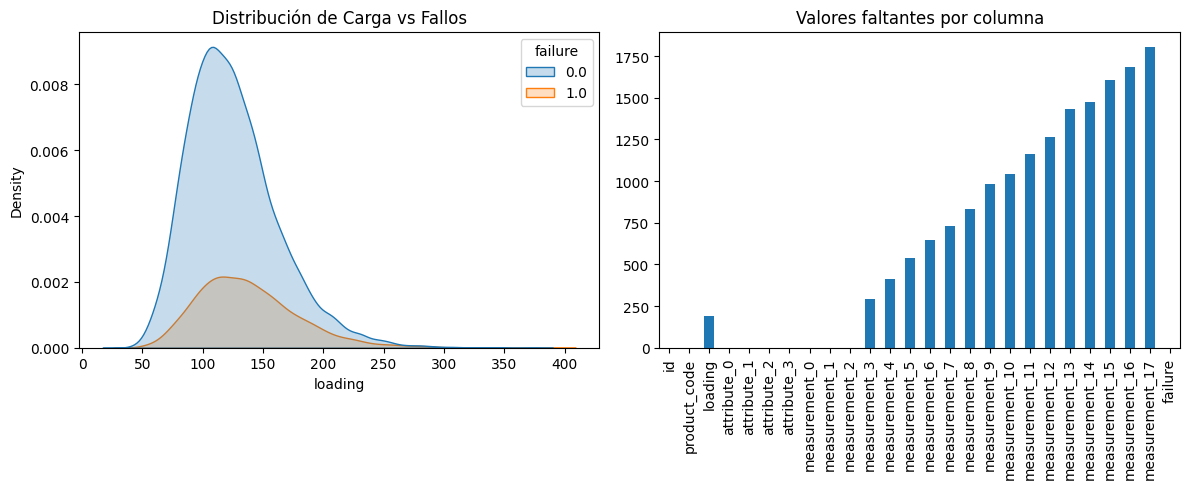

In [7]:
plt.figure(figsize=(12, 5))

# Subplot 1: Distribución de Loading
plt.subplot(1, 2, 1)
sns.kdeplot(data=train, x='loading', hue='failure', fill=True)
plt.title('Distribución de Carga vs Fallos')

# Subplot 2: Valores Nulos
plt.subplot(1, 2, 2)
train.isnull().sum().plot(kind='bar')
plt.title('Valores faltantes por columna')

plt.tight_layout()
plt.show()

3. Preprocesamiento de datos

In [8]:
# 1. Preparación inicial
test_ids = test['id']
y = train['failure']
X = train.drop(columns=['id', 'failure'])
X_test_final = test.drop(columns=['id'])

# Combinamos temporalmente para procesar igual
all_data = pd.concat([X, X_test_final])

# 2. Encoding de variables categóricas
le = LabelEncoder()
for col in ['attribute_0', 'attribute_1']:
    all_data[col] = le.fit_transform(all_data[col].astype(str))

# 3. Imputación (Rellenar NaNs con la media)
# Quitamos 'product_code' porque no es numérico y no se le puede sacar la media
cols_to_impute = all_data.drop(columns=['product_code']).columns
imputer = SimpleImputer(strategy='mean')
all_data[cols_to_impute] = imputer.fit_transform(all_data[cols_to_impute])

# 4. Escalar los datos (StandardScaler)
scaler = StandardScaler()
all_data[cols_to_impute] = scaler.fit_transform(all_data[cols_to_impute])

# 5. Separar de nuevo
X_final = all_data.iloc[:len(train)].drop(columns=['product_code'])
X_test_final = all_data.iloc[len(train):].drop(columns=['product_code'])

print("Procesamiento completado.")

Procesamiento completado.


4. Entrenamiento

In [ ]:
# Dividimos el train original: 80% para entrenar, 20% para validar
X_train_v, X_val, y_train_v, y_val = train_test_split(
    X_final, y, test_size=0.2, random_state=42, stratify=y
)

# Definimos el modelo
model = LogisticRegression(C=0.01, solver='liblinear', max_iter=500)

# Entrenamos
model.fit(X_train_v, y_train_v)

# Validamos
val_probs = model.predict_proba(X_val)[:, 1]
score = roc_auc_score(y_val, val_probs)

print(f"Puntuación ROC-AUC en Validación: {score:.4f}")

Puntuación ROC-AUC en Validación: 0.5664


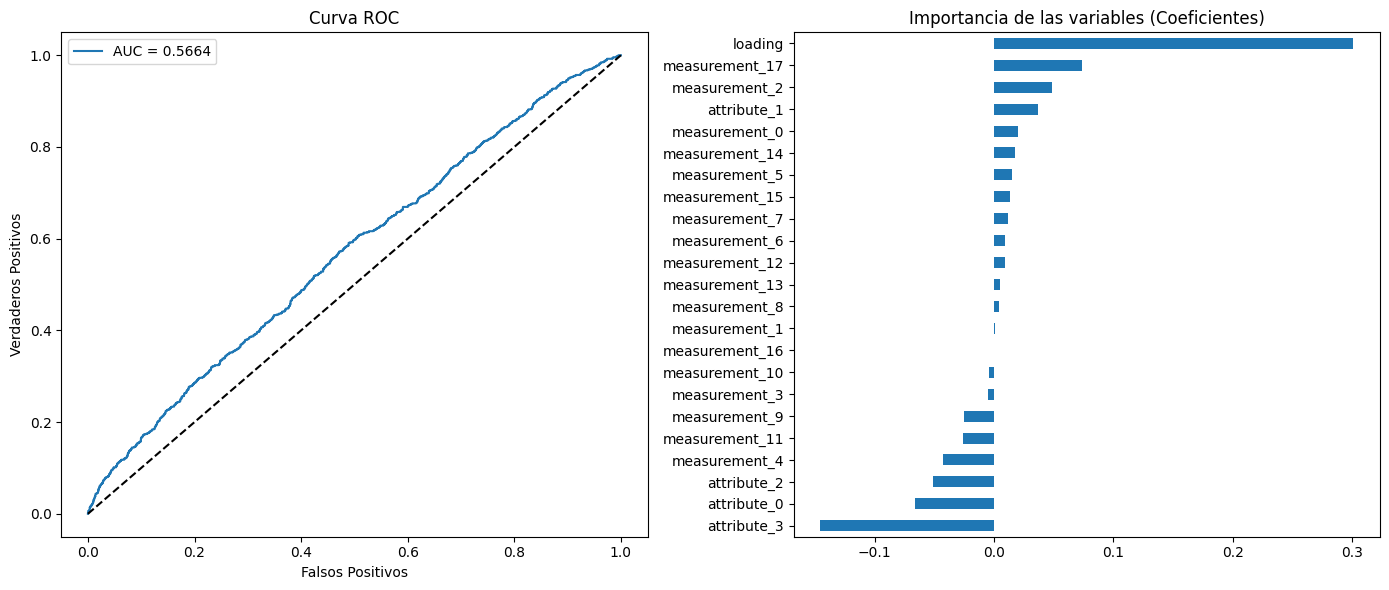

In [10]:
# Gráfico 1: Curva ROC
fpr, tpr, _ = roc_curve(y_val, val_probs)
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, label=f'AUC = {score:.4f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('Falsos Positivos')
plt.ylabel('Verdaderos Positivos')
plt.title('Curva ROC')
plt.legend()

# Gráfico 2: Importancia de las variables
importance = pd.Series(model.coef_[0], index=X_final.columns).sort_values()
plt.subplot(1, 2, 2)
importance.plot(kind='barh')
plt.title('Importancia de las variables (Coeficientes)')

plt.tight_layout()
plt.show()

## TASK 2: Evaluate the data drift

In [11]:
# 1. Copiamos los datos para no estropear los anteriores
df_train_drift = train.drop(columns=['failure', 'id']).copy()
df_test_drift = test.drop(columns=['id']).copy()

# 2. Creamos el target: 0 para train, 1 para test
df_train_drift['is_test'] = 0
df_test_drift['is_test'] = 1

# 3. Concatenamos
df_drift = pd.concat([df_train_drift, df_test_drift], axis=0).reset_index(drop=True)

print(f"Dataset combinado para drift: {df_drift.shape}")

Dataset combinado para drift: (41957, 25)


In [12]:
# Encoding y limpieza rápida
le_drift = LabelEncoder()
for col in ['product_code', 'attribute_0', 'attribute_1']:
    df_drift[col] = le_drift.fit_transform(df_drift[col].astype(str))

# Rellenar nulos
imputer_drift = SimpleImputer(strategy='mean')
X_drift = df_drift.drop(columns=['is_test'])
y_drift = df_drift['is_test']

X_drift_imputed = imputer_drift.fit_transform(X_drift)

# Dividir para validar
Xd_train, Xd_val, yd_train, yd_val = train_test_split(
    X_drift_imputed, y_drift, test_size=0.2, random_state=42, stratify=y_drift
)

# Entrenar modelo detector de drift
drift_detector = LogisticRegression(max_iter=1000)
drift_detector.fit(Xd_train, yd_train)

# Calcular el AUC
drift_probs = drift_detector.predict_proba(Xd_val)[:, 1]
drift_auc = roc_auc_score(yd_val, drift_probs)

print(f"ROC-AUC de detección de Drift: {drift_auc:.4f}")

ROC-AUC de detección de Drift: 1.0000


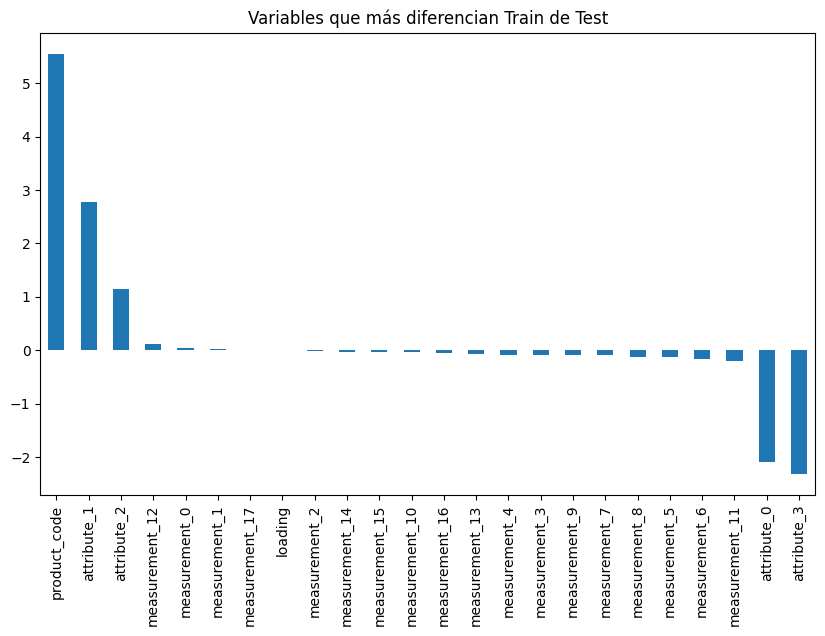

In [13]:
# Ver qué variables delatan que un dato es de test
drift_importance = pd.Series(drift_detector.coef_[0], index=X_drift.columns).sort_values(ascending=False)
plt.figure(figsize=(10, 6))
drift_importance.plot(kind='bar')
plt.title('Variables que más diferencian Train de Test')
plt.show()